# Starbucks Customer Feedback Intelligence & AI-Powered Customer Recovery System
### Python Foundations & Gen AI Internship Assessment
**Submitted by: Aiman Fathima**

## 1. Project Overview

In this project I take a Starbucks customer reviews dataset and do the following:

1. Load and clean the data
2. Find the critical (1 and 2 star) reviews using simple rules, with no machine learning
3. Find the most common complaint keywords and group complaints into categories
4. Give each critical review a simple priority score
5. Pick the top 3 critical reviews and use Google Gemini to draft an apology email for each
6. Add a human review step and a simulated outreach table

The reviews have no customer email addresses, so no real customer is ever contacted in this project.

## 2. Business Problem

A support team gets thousands of reviews every week. Reading all of them to find the urgent ones and writing apology emails by hand takes a lot of time.
This notebook filters the critical feedback automatically and drafts the first version of the reply, so a person only needs to review it.

Workflow: Review -> Rule-based analysis -> Priority -> GenAI response -> Human review -> Test email / log

## 3. Import Libraries

In [1]:
import os
import re
import getpass
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 80)

In [29]:
import sys
print(sys.executable)

C:\Users\Aiman Fathima\AppData\Local\Programs\Python\Python312\python.exe


In [30]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "google-genai"
])

0

In [31]:
from google import genai

print("Google GenAI installed successfully!")

Google GenAI installed successfully!


## 4. Load Dataset

In [2]:
df = pd.read_csv("reviews_data.csv")
print("Loaded reviews_data.csv")

Loaded reviews_data.csv


## 5. Initial Data Inspection

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", list(df.columns))

Rows: 850
Columns: 6
Column names: ['name', 'location', 'Date', 'Rating', 'Review', 'Image_Links']


In [4]:
df.head()

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwest Parkway are always so warm a...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,"** at the Starbucks by the fire station on 436 in Altamonte Springs, FL made...",['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize a Starbucks employee Billy at...,['https://media.consumeraffairs.com/files/cache/reviews/starbucks_804950_thu...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card didn’t work. Thankful the wor...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm water. I work for Instacart righ...,['https://media.consumeraffairs.com/files/cache/reviews/starbucks_793785_thu...


In [5]:
df.dtypes

name               str
location           str
Date               str
Rating         float64
Review             str
Image_Links        str
dtype: object

In [6]:
df.isnull().sum()

name             0
location         0
Date             0
Rating         145
Review           0
Image_Links      0
dtype: int64

In [7]:
# value_counts with dropna=False so the missing ratings are also counted
df["Rating"].value_counts(dropna=False).sort_index()

Rating
1.0    451
2.0     99
3.0     33
4.0     39
5.0     83
NaN    145
Name: count, dtype: int64

What I noticed from the inspection:

- `Rating` is the star rating (1 to 5) and `Review` is the review text. `location` is written like "City, ST".
- There is no email column in this dataset.
- `Rating` has missing values. Those reviews have text but no star rating, so I cannot say if they are critical.

## 6. Data Cleaning

In [8]:
# 1. Check duplicates
print("Rows before cleaning:", len(df))
print("Duplicate review texts:", df.duplicated(subset="Review").sum())

Rows before cleaning: 850
Duplicate review texts: 36


In [9]:
# 2. Remove duplicate review texts (the same text should not be counted twice)
df = df.drop_duplicates(subset="Review").copy()

# 3. Missing values
# Review text and location: fill with a simple default
df["Review"] = df["Review"].fillna("")
df["location"] = df["location"].fillna("Unknown")

# Rating: I do NOT fill these in. Guessing a rating would be made-up data,
# so unrated reviews are kept but left out of the rating based analysis.
print("Rows after removing duplicates:", len(df))
print("Reviews with no rating:", df["Rating"].isnull().sum())

Rows after removing duplicates: 814
Reviews with no rating: 110


In [10]:
# 4. Clean the review text with basic string methods
def clean_text(text):
    text = text.lower()
    text = text.replace("'", "").replace("\u2019", "")   # don't -> dont
    text = re.sub(r"[^a-z\s]", " ", text)                # remove numbers, ** and special characters
    text = re.sub(r"\s+", " ", text).strip()             # remove extra spaces
    return text

df["clean_review"] = df["Review"].apply(clean_text)
df["review_words"] = df["clean_review"].str.split().str.len()

# 5. State column from the location (the last part after the comma)
df["state"] = df["location"].str.split(",").str[-1].str.strip().str.upper()

df[["Review", "clean_review"]].head(3)

,Review,clean_review
0,Amber and LaDonna at the Starbucks on Southwest Parkway are always so warm a...,amber and ladonna at the starbucks on southwest parkway are always so warm a...
1,"** at the Starbucks by the fire station on 436 in Altamonte Springs, FL made...",at the starbucks by the fire station on in altamonte springs fl made my day ...
2,I just wanted to go out of my way to recognize a Starbucks employee Billy at...,i just wanted to go out of my way to recognize a starbucks employee billy at...


Here I removed duplicate reviews, handled the missing values and cleaned the text (lowercase, no special characters, no extra spaces).
I kept the original `Review` column as well, because the emails should be based on the real text.

## 7. Exploratory Analysis

In [11]:
# only reviews that have a rating
rated = df[df["Rating"].notnull()].copy()
rated["Rating"] = rated["Rating"].astype(int)

print("Total reviews:", len(df))
print("Rated reviews:", len(rated))
print("Average rating:", round(rated["Rating"].mean(), 2))
print("Average review length (words):", round(df["review_words"].mean()))

Total reviews: 814
Rated reviews: 704
Average rating: 1.87
Average review length (words): 91


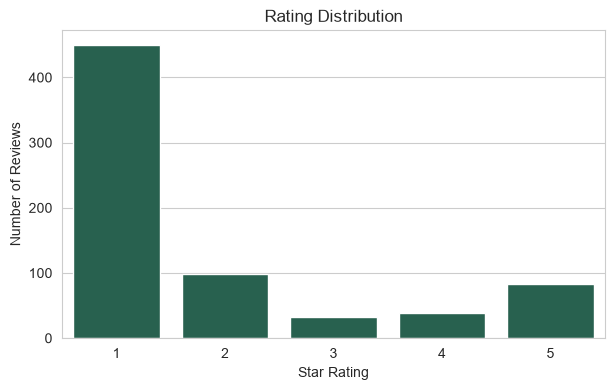

In [12]:
rating_counts = rated["Rating"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values, color="#1e6b52")
plt.title("Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()

Most rated reviews are negative. 450 of the 704 rated reviews are 1 star, which is about 64 percent, and only 83 are 5 stars.

## 8. Rule-Based Critical Review Detection

Rule: a review with a rating of 1 or 2 stars is a **Critical** review. No machine learning is used here.

In [13]:
critical = rated[rated["Rating"] <= 2].copy()
non_critical = rated[rated["Rating"] > 2]

print("Critical reviews (1-2 stars):", len(critical))
print("Non-critical reviews (3-5 stars):", len(non_critical))
print("Critical percentage:", round(len(critical) / len(rated) * 100, 1), "%")

Critical reviews (1-2 stars): 549
Non-critical reviews (3-5 stars): 155
Critical percentage: 78.0 %


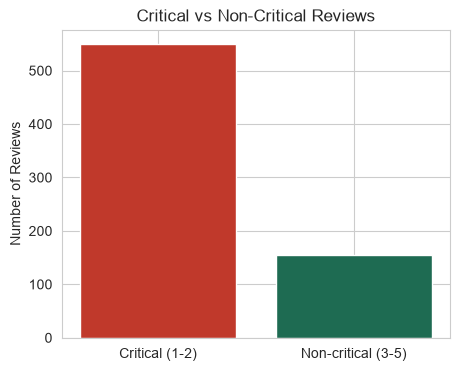

In [14]:
plt.figure(figsize=(5, 4))
plt.bar(["Critical (1-2)", "Non-critical (3-5)"], [len(critical), len(non_critical)], color=["#c0392b", "#1e6b52"])
plt.title("Critical vs Non-Critical Reviews")
plt.ylabel("Number of Reviews")
plt.show()

About 78 percent of the rated reviews (549 out of 704) are critical, and most of them are 1 star. This dataset is clearly skewed towards unhappy customers.

## 9. Complaint Keyword Analysis

First I look at the most common words in the critical reviews. I use a small stopword list so that words like "the" and "and" do not fill the list.

In [15]:
stopwords = set("""
a about after all also am an and any are as at be because been before but by can could did do does dont
for from had has have he her him his how i if in into is it its just me my no not of on one only or our out
she so some than that the their them then there they this to too up us was we were what when which who will
with would you your im ive got get go went said says told asked ask like even back again now still
""".split())

def get_top_words(texts, n=20):
    counter = Counter()
    for text in texts:
        for word in text.split():
            if word not in stopwords and len(word) > 2:
                counter[word] += 1
    return counter.most_common(n)

top_words = get_top_words(critical["clean_review"], 20)
for word, count in top_words:
    print(word, "-", count)

starbucks - 776
coffee - 395
customer - 220
drink - 210
service - 180
store - 179
time - 175
order - 167
card - 161
very - 136
never - 115
ordered - 112
manager - 104
cup - 98
money - 97
customers - 95
over - 87
more - 87
didnt - 85
day - 84


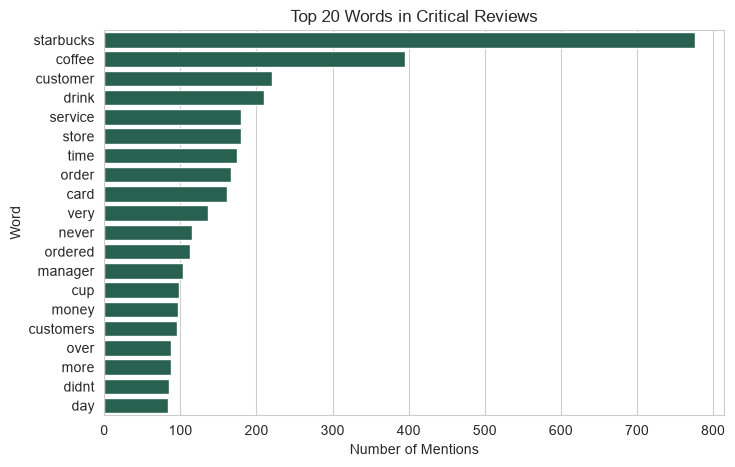

In [16]:
words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(8, 5))
sns.barplot(x=counts, y=words, color="#1e6b52")
plt.title("Top 20 Words in Critical Reviews")
plt.xlabel("Number of Mentions")
plt.ylabel("Word")
plt.show()

Most of the top words are general words like "coffee" or "order", which show up in all reviews.
So I also count a list of specific complaint keywords, closer to the "rude", "late", "broken" idea in the assignment.

In [17]:
complaint_keywords = [
    "rude", "attitude", "unprofessional", "ignored", "manager",
    "wrong", "cold", "stale", "burnt", "hair", "dirty",
    "wait", "waiting", "slow", "minutes", "closed",
    "charged", "refund", "paid", "price", "expensive",
    "app", "card", "balance", "payment",
]

def count_complaint_keywords(texts, keywords):
    counter = Counter()
    for text in texts:
        words_in_review = set(text.split())   # set so one review counts a keyword once
        for keyword in keywords:
            if keyword in words_in_review:
                counter[keyword] += 1
    return counter.most_common()

keyword_counts = count_complaint_keywords(critical["clean_review"], complaint_keywords)
keyword_df = pd.DataFrame(keyword_counts, columns=["keyword", "critical_reviews_mentioning"])
keyword_df.head(15)

,keyword,critical_reviews_mentioning
0,card,73
1,manager,69
2,rude,58
3,minutes,37
4,wrong,32
5,wait,27
6,paid,26
7,waiting,24
8,price,22
9,charged,20


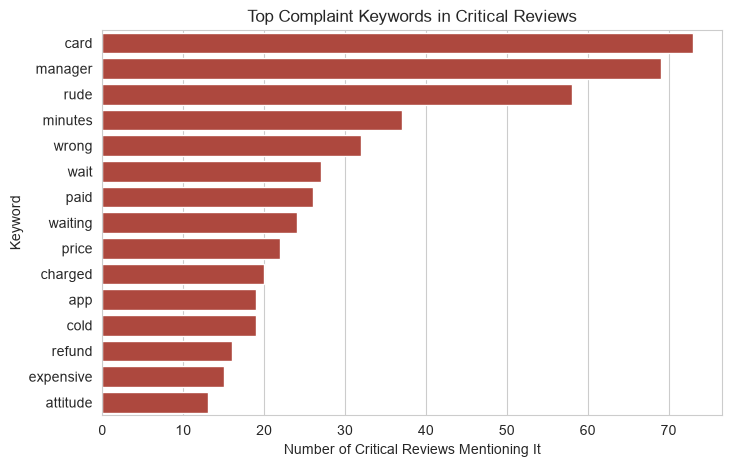

In [18]:
top15 = keyword_df.head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=top15["critical_reviews_mentioning"], y=top15["keyword"], color="#c0392b")
plt.title("Top Complaint Keywords in Critical Reviews")
plt.xlabel("Number of Critical Reviews Mentioning It")
plt.ylabel("Keyword")
plt.show()

The most mentioned complaint keywords are card (73 reviews), manager (69) and rude (58), followed by minutes (37) and wrong (32). So people complain about people and money more than about the drink itself. Words like card, manager and minutes can also be used in neutral ways, so these counts only show the topic, not always the exact complaint.

## 10. Complaint Categorization

Next I group the keywords into complaint categories. These are simple rule-based categories: if a review contains words from a category, it gets that category.
I only used categories that actually show up in the review text (checked in the keyword counts above).

In [19]:
categories = {
    "Staff / Service": ["rude", "attitude", "unprofessional", "ignored", "manager", "employee", "barista", "staff", "yelled"],
    "Product Quality": ["cold", "stale", "burnt", "taste", "hair", "bitter", "watery"],
    "Waiting Time": ["wait", "waiting", "slow", "minutes", "queue", "hour"],
    "Pricing / Billing": ["charged", "charge", "refund", "paid", "price", "expensive", "money", "overcharged"],
    "Order / Payment / App": ["wrong", "app", "mobile", "payment", "card", "balance", "reload", "rewards"],
    "Store Experience": ["dirty", "bathroom", "closed", "crowded", "parking", "seating"],
}

def find_categories(clean_review):
    words_in_review = set(clean_review.split())
    matches = {}
    for category, keywords in categories.items():
        hits = 0
        for keyword in keywords:
            if keyword in words_in_review:
                hits += 1
        if hits > 0:
            matches[category] = hits
    return matches

def get_main_category(clean_review):
    matches = find_categories(clean_review)
    if len(matches) == 0:
        return "Other / General"
    # category with the most keyword hits (first one wins if tied)
    return max(matches, key=matches.get)

critical["main_category"] = critical["clean_review"].apply(get_main_category)
critical["num_categories"] = critical["clean_review"].apply(lambda t: len(find_categories(t)))

critical["main_category"].value_counts()

main_category
Staff / Service          170
Other / General          131
Pricing / Billing         93
Order / Payment / App     62
Waiting Time              47
Product Quality           35
Store Experience          11
Name: count, dtype: int64

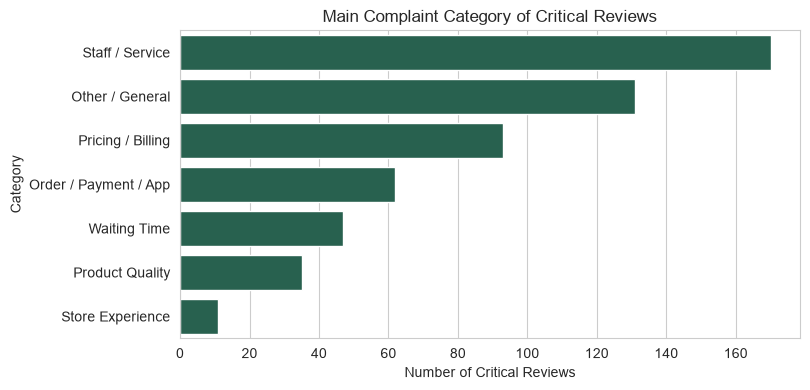

In [20]:
category_counts = critical["main_category"].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=category_counts.values, y=category_counts.index, color="#1e6b52")
plt.title("Main Complaint Category of Critical Reviews")
plt.xlabel("Number of Critical Reviews")
plt.ylabel("Category")
plt.show()

Staff / Service is the biggest complaint category (170 critical reviews), then Pricing / Billing (93) and Order / Payment / App (62). 131 reviews did not match any keyword list, so they are marked Other / General. This is a keyword method, so a review can be put in a slightly wrong category.

## 11. Priority Scoring

This is a simple project-level rule I made to decide which critical reviews to look at first. It is not a validated model, only a transparent way to sort the cases.

| Rule | Points |
|---|---|
| 1-star review | +3 |
| 2-star review | +2 |
| Contains a strong complaint word | +2 |
| Long, detailed review (100 words or more) | +1 |
| Complaint fits 2 or more categories | +2 |

Levels: score 7 or more is **Urgent**, 5 to 6 is **High**, below 5 is **Moderate**.

In [21]:
strong_words = [
    "rude", "unprofessional", "disgusting", "worst", "terrible", "horrible", "awful",
    "unacceptable", "refund", "sick", "scam", "fraud", "stole", "lawsuit", "hair",
]

def calculate_priority(row):
    score = 0

    if row["Rating"] == 1:
        score += 3
    elif row["Rating"] == 2:
        score += 2

    words_in_review = set(row["clean_review"].split())
    for word in strong_words:
        if word in words_in_review:
            score += 2
            break          # only add the points once

    if row["review_words"] >= 100:
        score += 1

    if row["num_categories"] >= 2:
        score += 2

    return score

def get_priority_level(score):
    if score >= 7:
        return "Urgent"
    elif score >= 5:
        return "High"
    else:
        return "Moderate"

critical["priority_score"] = critical.apply(calculate_priority, axis=1)
critical["priority"] = critical["priority_score"].apply(get_priority_level)

critical["priority"].value_counts()

priority
Moderate    277
High        208
Urgent       64
Name: count, dtype: int64

In [22]:
critical[["Rating", "main_category", "review_words", "priority_score", "priority"]].head()

,Rating,main_category,review_words,priority_score,priority
5,1,Staff / Service,61,3,Moderate
6,1,Product Quality,45,3,Moderate
7,1,Other / General,101,4,Moderate
8,1,Pricing / Billing,44,5,High
9,1,Staff / Service,86,7,Urgent


## 12. Location Analysis

In [23]:
# Using all rated reviews. State comes from the "City, ST" location.
rated["is_critical"] = rated["Rating"] <= 2

location_summary = rated.groupby("state").agg(
    total_reviews=("Rating", "size"),
    critical_reviews=("is_critical", "sum"),
)
location_summary["critical_percent"] = (location_summary["critical_reviews"] / location_summary["total_reviews"] * 100).round(1)

# "OTHER" is how the dataset labels locations outside the US, so I leave it out
location_summary = location_summary.drop(index="OTHER", errors="ignore")

print("Top 5 states by number of critical reviews")
display(location_summary.sort_values("critical_reviews", ascending=False).head(5))

# percentage only makes sense with enough reviews, so at least 10 rated reviews per state
enough = location_summary[location_summary["total_reviews"] >= 10]
print("Top 5 states by critical percentage (at least 10 rated reviews)")
display(enough.sort_values("critical_percent", ascending=False).head(5))

Top 5 states by number of critical reviews


,total_reviews,critical_reviews,critical_percent
state,,,
CA,142,114,80.3
FL,41,33,80.5
WA,34,29,85.3
NY,31,27,87.1
TX,37,27,73.0


Top 5 states by critical percentage (at least 10 rated reviews)


,total_reviews,critical_reviews,critical_percent
state,,,
GA,23,21,91.3
NC,23,21,91.3
OH,17,15,88.2
NY,31,27,87.1
WA,34,29,85.3


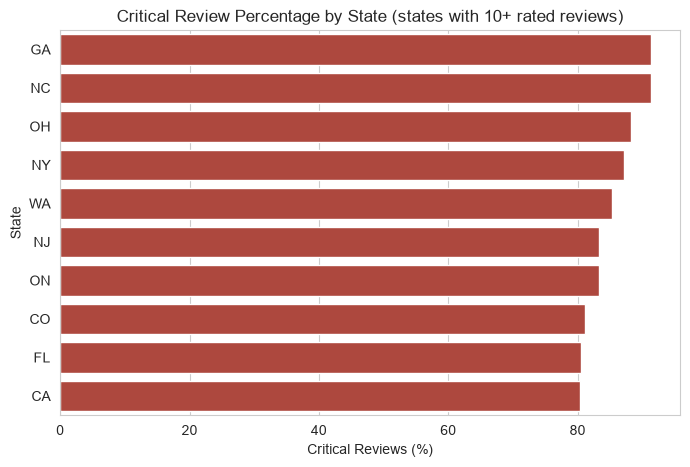

In [24]:
top_states = enough.sort_values("critical_percent", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_states["critical_percent"], y=top_states.index, color="#c0392b")
plt.title("Critical Review Percentage by State (states with 10+ rated reviews)")
plt.xlabel("Critical Reviews (%)")
plt.ylabel("State")
plt.show()

California has the most critical reviews (114), but that is mostly because it has the most reviews overall. Its critical percentage is about 80 percent, close to the overall average. Georgia and North Carolina have the highest critical percentage (about 91 percent), but they only have 23 rated reviews each, so I would not draw strong conclusions from that.

## 13. Top 3 Customer Recovery Cases

Selection rule (no hand picking): sort the critical reviews by priority score, and if the score is the same, by review length (longer means more detail). The first 3 are selected.

In [25]:
top3 = critical.sort_values(["priority_score", "review_words"], ascending=[False, False]).head(3).copy()

for index, row in top3.iterrows():
    print("Review ID:", index)
    print("Rating:", row["Rating"])
    print("Location:", row["location"])
    print("Complaint category:", row["main_category"])
    print("Priority:", row["priority"], "(score", row["priority_score"], ")")
    print("Review:", row["Review"])
    print("-" * 80)

Review ID: 645
Rating: 1
Location: Houston, tx
Complaint category: Staff / Service
Priority: Urgent (score 8 )
Review: Because the incompetent manager, **, at store no. 6723 does not like me, she called a cop on me and told the cop lies about me and said I was barred from the store and the other Starbucks in the district. Since when does a store manager dictate the policies for the district? On that same day, she served me coffee and a brownie a half hour before the cop showed up. She set me up. Before that happened, I was regular loyal customer, and I told my friends and relatives about this incident. They are going to cut up their gold cards.The worst part of this was that the fool manager and the cop yelled at me to get out of the store and the idiot cop did not want to hear my side. I was humiliated in front of the employees and the customers, and that moron, the district manager, won't help me and she loves her. I believe nobody at Starbucks will help me. Maybe it's a blessing in 

## 14. GenAI Response Generation (Google Gemini)

The assignment allows OpenAI, Gemini or HuggingFace. I use the Google Gemini free API.

The API key is never written in the code. It is read from an environment variable called `GEMINI_API_KEY`. If it is not set, the cell below asks for it. Steps to get a free key are in the README.

In [39]:
from google import genai
import os
import getpass
import time

# Get API key
api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    api_key = getpass.getpass(
        "Enter your Gemini API key (not shown, not saved): "
    )

# Create Gemini client
client = genai.Client(api_key=api_key)

# Current Gemini model
MODEL_NAME = "gemini-3.5-flash-lite"

print("Gemini client is ready!")

Enter your Gemini API key (not shown, not saved):  ········


Gemini client is ready!


In [40]:
def build_prompt(row):
    customer_name = "Customer"

    if "name" in row and isinstance(row["name"], str) and row["name"].strip() != "":
        customer_name = row["name"].strip()

    prompt = f"""You are a Customer Support Agent at Starbucks.

Write a short, personalized and empathetic apology email to a customer who left a negative review.

Customer name: {customer_name}
Rating: {row["Rating"]} out of 5
Complaint category: {row["main_category"]}
Priority: {row["priority"]}

Customer review:
"{row["Review"]}"

Instructions:
- Start with a subject line in the format "Subject: ..."
- Address the customer by first name
- Mention the specific problem described in the review
- Apologize sincerely and stay professional
- Keep the email under 130 words
- Do not use generic wording
- Do NOT promise refunds, vouchers, compensation, investigations or any company policy
- Do NOT repeat the names of individual employees from the review
- Do not add anything that is not in the review
- Do not take sides, do not admit fault and do not agree with accusations about staff or others
- Do not repeat insults or rude words from the review
- Sign off as "Starbucks Customer Support Team"
"""

    return prompt


def generate_email(prompt):

    # Try up to 3 times if Gemini is temporarily unavailable
    for attempt in range(3):

        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt
            )

            return response.text.strip()

        except Exception as error:

            print(
                f"Attempt {attempt + 1} failed:"
            )
            print(error)

            # Retry only for temporary server problems
            if "503" in str(error):

                if attempt < 2:
                    print("Gemini is busy. Waiting 10 seconds before retry...")
                    time.sleep(10)
                else:
                    print("Gemini is still unavailable after 3 attempts.")

            else:
                print("This is not a temporary 503 error.")
                break

    return ""


# Generate emails for the top 3 critical reviews
generated_emails = []

for index, row in top3.iterrows():

    print(f"\nGenerating email {len(generated_emails) + 1}...")

    prompt = build_prompt(row)

    email_text = generate_email(prompt)

    generated_emails.append(email_text)


# Add generated emails to the dataframe
top3["generated_email"] = generated_emails


# Count successful emails
successful_emails = sum(
    1 for email in generated_emails
    if email != ""
)

print("\nEmails generated:", successful_emails)


Generating email 1...

Generating email 2...

Generating email 3...

Emails generated: 3


## 15. Generated Emails

The three AI-generated emails are displayed below (rendered as Markdown when the notebook is run).

In [41]:
for index, row in top3.iterrows():
    display(Markdown(f"### Review ID {index} | {row['Rating']} star | {row['main_category']} | {row['priority']} priority"))
    display(Markdown("**Original review:**"))
    display(Markdown("> " + row["Review"].replace("\n", " ")))
    display(Markdown("**AI-generated email (draft):**"))
    display(Markdown(row["generated_email"].replace("\n", "  \n")))
    display(Markdown("---"))

### Review ID 645 | 1 star | Staff / Service | Urgent priority

**Original review:**

> Because the incompetent manager, **, at store no. 6723 does not like me, she called a cop on me and told the cop lies about me and said I was barred from the store and the other Starbucks in the district. Since when does a store manager dictate the policies for the district? On that same day, she served me coffee and a brownie a half hour before the cop showed up. She set me up. Before that happened, I was regular loyal customer, and I told my friends and relatives about this incident. They are going to cut up their gold cards.The worst part of this was that the fool manager and the cop yelled at me to get out of the store and the idiot cop did not want to hear my side. I was humiliated in front of the employees and the customers, and that moron, the district manager, won't help me and she loves her. I believe nobody at Starbucks will help me. Maybe it's a blessing in disguise that people find out about this horrible company, because there are better coffee companies out there.

**AI-generated email (draft):**

Subject: Regarding your recent visit to store no. 6723  
  
Hi Phil,  
  
Thank you for reaching out to us. I am deeply sorry to hear about your recent experience at store no. 6723 and the distress caused by the interaction involving the police, being asked to leave, and feeling humiliated in front of others.   
  
We take feedback regarding our store environments and customer service very seriously. It is never our intention for any customer to feel unwelcome or unsupported by our management teams, and I understand how upsetting it is to feel that your concerns were not addressed by our district leadership.   
  
We appreciate you sharing your perspective with us, Phil, and I regret that this situation led you to reconsider your relationship with Starbucks.   
  
Sincerely,  
  
Starbucks Customer Support Team

...

**Original review:**

> I recently began purchasing coffee each morning at Starbucks at 'The River' mall in Rancho Mirage CA. The staff is completely incompetent and so I presume also the management as well. I am a 51 year old business major so I think I'm qualified to make this critique. One woman with curly grey hair particularly annoys me with her arrogance and flippant demeanor towards me. I ask for creamer or what the flavors of coffee are because a half hour after they open there are no signs on the coffee of the day board. She acts like I kicked her dog or something. Another woman tells me on Sunday when they're supposed to open at 5:30 that she's sorry but a manager failed to show up that morning. I have to think this an untruth because I know of no manager that shows up at 5:00 am on a Sunday. If competent help were available I see no need for a manager to be there. And if not, yet another poor service from this coffee shop. 

**AI-generated email (draft):**

Subject: Regarding your recent visit to our Starbucks at The River  
  
Hi Dennis,  
  
Thank you for reaching out to us. I am truly sorry to hear about your recent experiences at our location in Rancho Mirage.   
  
It is deeply concerning to learn that you felt disrespected by a team member when asking questions about our coffee, and that you encountered a delayed opening on Sunday morning due to staffing issues. We aim to provide a welcoming environment and reliable service every single day, and I regret that we fell short of those standards during your morning visits.   
  
Your feedback has been shared with the appropriate leadership team so they are fully aware of your concerns regarding customer service and store operations.   
  
We appreciate you taking the time to share your perspective with us.   
  
Sincerely,  
  
Starbucks Customer Support Team

---

## 16. Human Review and Simulated Email Workflow

The AI emails are only drafts. A person must read each one before anything is sent.

The dataset has no customer email addresses, so this table is a **simulated customer outreach log**. No real customer is contacted.

Status meaning:
- Ready for Review: the draft is generated and waiting for a person
- Approved for Test: a person read it and approved it for a test send
- Sent to Test Address: sent to my own test email only (see Additional Upgrades)

In [42]:
# After reading the emails above, add the Review IDs I approve into this list
approved_ids = []     # example: approved_ids = [123, 456]

def get_status(review_id):
    if review_id in approved_ids:
        return "Approved for Test"
    return "Ready for Review"

email_log = pd.DataFrame({
    "Review ID": top3.index,
    "Rating": top3["Rating"].values,
    "Complaint": top3["main_category"].values,
    "Priority": top3["priority"].values,
    "Generated Response": top3["generated_email"].values,
})
email_log["Email Status"] = email_log["Review ID"].apply(get_status)

email_log

,Review ID,Rating,Complaint,Priority,Generated Response,Email Status
0,645,1,Staff / Service,Urgent,"Subject: Regarding your recent visit to store no. 6723\n\nHi Phil,\n\nThank ...",Ready for Review
1,694,1,Waiting Time,Urgent,"Subject: Regarding your recent visit to our Miller Park store\n\nHi Marcie,\...",Ready for Review
2,563,1,Staff / Service,Urgent,Subject: Regarding your recent visit to our Starbucks at The River\n\nHi Den...,Ready for Review


## 17. Additional Upgrades: Sending the Approved Emails to a Test Address

This part goes beyond the assignment. Since the dataset has no customer emails, the code below can only send to **my own test address**, never to a reviewer.
It stays switched off (`SEND_TEST_EMAILS = False`) unless I turn it on. It only sends emails marked "Approved for Test".

To use it with a Gmail account I control, I set three environment variables (explained in the README): `EMAIL_ADDRESS`, `EMAIL_APP_PASSWORD` and `TEST_EMAIL_ADDRESS`.

In [44]:
import smtplib
from email.message import EmailMessage

SEND_TEST_EMAILS = False     # change to True only when I want to test sending

def split_subject_and_body(email_text):
    lines = email_text.split("\n")
    subject = "Starbucks Customer Support (test email)"
    if lines[0].lower().startswith("subject:"):
        subject = lines[0][len("subject:"):].strip()
        lines = lines[1:]
    body = "\n".join(lines).strip()
    return subject, body

def send_test_email(to_address, subject, body):
    sender = os.getenv("EMAIL_ADDRESS")
    app_password = os.getenv("EMAIL_APP_PASSWORD")

    message = EmailMessage()
    message["From"] = sender
    message["To"] = to_address
    message["Subject"] = "[TEST] " + subject
    message.set_content(body)

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
        server.login(sender, app_password)
        server.send_message(message)

if SEND_TEST_EMAILS:
    test_address = os.getenv("TEST_EMAIL_ADDRESS")
    if not test_address:
        print("Set TEST_EMAIL_ADDRESS to an email address that I own first.")
    else:
        for i, row in email_log.iterrows():
            if row["Email Status"] == "Approved for Test":
                subject, body = split_subject_and_body(row["Generated Response"])
                send_test_email(test_address, subject, body)
                email_log.loc[i, "Email Status"] = "Sent to Test Address"
                print("Sent test email for review", row["Review ID"], "to", test_address)
else:
    print("Test sending is switched off (SEND_TEST_EMAILS = False). To send mails we have to add the customers mail id and switch on the test emails- we make it True")

Test sending is switched off (SEND_TEST_EMAILS = False). To send mails we have to add the customers mail id and switch on the test emails- we make it True


## 18. Executive Summary

In [45]:
generated_count = sum(1 for e in top3["generated_email"] if e != "")
top_categories = critical["main_category"].value_counts().head(3)

print("Total reviews analyzed (after removing duplicates):", len(df))
print("Reviews with a rating:", len(rated))
print("Reviews without a rating:", len(df) - len(rated))
print("Critical reviews (1-2 stars):", len(critical))
print("Urgent priority cases:", (critical["priority"] == "Urgent").sum())
print("Top complaint areas:", ", ".join(top_categories.index))
print("GenAI responses generated:", generated_count)

Total reviews analyzed (after removing duplicates): 814
Reviews with a rating: 704
Reviews without a rating: 110
Critical reviews (1-2 stars): 549
Urgent priority cases: 64
Top complaint areas: Staff / Service, Other / General, Pricing / Billing
GenAI responses generated: 3


## 19. Key Insights

Data -> Insight:

- 814 reviews after removing duplicates, 704 with a rating, 549 critical (78 percent).
- Staff / Service is the top complaint category (170 critical reviews), and the word "rude" appears in 58 critical reviews.
- Pricing / Billing (93) and Order / Payment / App (62) together make a large group of money and payment problems, and the word "card" is the most mentioned keyword (73).
- Waiting time is mentioned too (47 reviews in this category, "minutes" in 37).
- Only a small part of the critical reviews are about the product itself (Product Quality, 35 reviews).
- 64 critical reviews are Urgent priority and 208 are High priority.
- The location differences are small and based on few reviews per state, so they are not strong evidence.

## 20. Recommended Actions

Insight -> Possible business action:

- Staff / Service is the biggest group, so the first action would be to review customer service and manager behaviour training at the stores that appear most in these complaints.
- Many complaints are about money and cards (billing, refunds, gift cards), so the support team could check how refund and card problems are handled and how clearly it is explained to customers.
- Waiting time complaints could be checked with real store data, for example the busiest hours.
- The support team can start with the Urgent cases (64) and use the GenAI drafts as a first version, with a person reviewing every email before it goes out.
- Before changing anything by location, collect more reviews per state, because the current numbers are small.

## 21. Conclusion

I built a simple rule-based system that finds critical reviews (1 to 2 stars), groups the complaints with keywords, gives each case a priority score, selects the top 3 cases with a clear rule and uses Google Gemini to draft apology emails. A human review step comes before any outreach, and the outreach itself is only simulated because the dataset has no email addresses.

Limits: the keyword categories are simple and can be wrong for some reviews, 110 reviews had no rating and were left out of the rating analysis, and the priority score is a project-level rule and not a validated model.